In [79]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

In [81]:
import pandas as pd

file_path = r"C:\Users\rimap\Desktop\Capstone\final_restaurant_data.csv"
df = pd.read_csv(file_path)

print(df.shape)
print(df.head(3))
print(df.dtypes)
print("Missing per column:\n", df.isna().sum().sort_values(ascending=False).head(10))

(8368, 21)
   dummy_location  dummy_Japanese  dummy_Mexican  dummy_Italian  dummy_Indian  \
0               1               1              0              0             0   
1               0               0              1              0             0   
2               1               0              0              1             0   

   dummy_French  Rating  Seating_Capacity  Average_Meal_Price  \
0             0     4.0                38               73.98   
1             0     3.2                76               28.11   
2             0     4.7                48               48.29   

   Marketing_Budget  ...  Chef_Experience_Years  Number_of_Reviews  \
0              2224  ...                     13                185   
1              4416  ...                      8                533   
2              2796  ...                     18                853   

   Avg_Review_Length  Ambience_Score  Service_Quality_Score  \
0         161.924906             1.3                    7.0

In [83]:
drop_cols = [c for c in ["Name","Cuisine","Location","ParkingAvailability","dummy_American"] if c in df.columns]

data = df.drop(columns=drop_cols, errors="ignore")

assert "Revenue" in data.columns, "Revenue column missing!"

In [85]:
X = data.drop(columns=["Revenue"])
y = data["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [87]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

lin = LinearRegression().fit(X_train, y_train)
rf  = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_train, y_train)

pred_lin = lin.predict(X_test)
pred_rf  = rf.predict(X_test)

comparison = pd.DataFrame({
    "Actual_Revenue": y_test.values,
    "Predicted_Revenue": pred_lin
})

def eval_row(name, y_true, y_pred):
    return {
        "Model": name,
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }

metrics = pd.DataFrame([
    eval_row("Linear Regression", y_test, pred_lin),
    eval_row("Random Forest",    y_test, pred_rf),
])

metrics

,Model,R2,MAE,RMSE
0,Linear Regression,0.955449,43206.524558,56506.866953
1,Random Forest,0.999240,5731.884339,7380.315870


In [89]:
metrics_path = r"C:\Users\rimap\Desktop\Capstone\metrics_table.csv"
metrics.to_csv(metrics_path, index=False)
print("Saved:", metrics_path)

Saved: C:\Users\rimap\Desktop\Capstone\metrics_table.csv


In [91]:
fi = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

fi_path = r"C:\Users\rimap\Desktop\Capstone\feature_importance.csv"
fi.to_csv(fi_path, index=False)
print("Saved:", fi_path)

fi.head(10)

Saved: C:\Users\rimap\Desktop\Capstone\feature_importance.csv


,feature,importance
7,Seating_Capacity,0.504865
8,Average_Meal_Price,0.492786
0,dummy_location,0.000654
11,Chef_Experience_Years,0.000231
13,Avg_Review_Length,0.000127
14,Ambience_Score,0.000127
12,Number_of_Reviews,0.000125
1,dummy_Japanese,0.000125
15,Service_Quality_Score,0.000124
9,Marketing_Budget,0.000119


In [93]:
print("Mean Actual Revenue:", df['Revenue'].mean())
print("Mean Predicted Revenue (Linear):", pred_lin.mean())
print("Mean Predicted Revenue (Random Forest):", pred_rf.mean())

Mean Actual Revenue: 656070.5633508605
Mean Predicted Revenue (Linear): 655186.506839089
Mean Predicted Revenue (Random Forest): 653690.7461639189


Saved: C:\Users\rimap\Desktop\Capstone\pred_vs_actual_rf.png


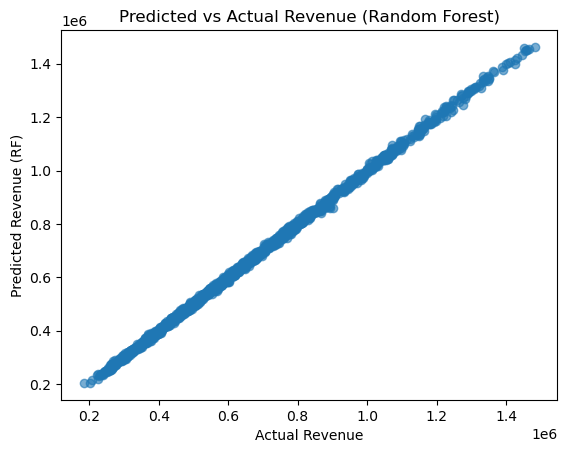

Saved: C:\Users\rimap\Desktop\Capstone\feature_importance_top10.png


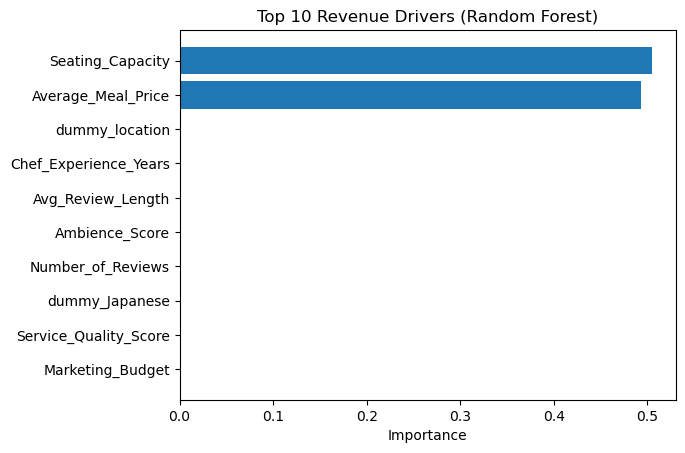

In [95]:
# (a) Predicted vs Actual (RF)
plt.figure()
plt.scatter(y_test, pred_rf, alpha=0.6)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue (RF)")
plt.title("Predicted vs Actual Revenue (Random Forest)")
pvapath = r"C:\Users\rimap\Desktop\Capstone\pred_vs_actual_rf.png"
plt.savefig(pvapath, bbox_inches="tight", dpi=144)
print("Saved:", pvapath)
plt.show()

# (b) Top 10 Features (RF)
topk = fi.head(10).sort_values("importance")
plt.figure()
plt.barh(topk["feature"], topk["importance"])
plt.xlabel("Importance")
plt.title("Top 10 Revenue Drivers (Random Forest)")
fipath = r"C:\Users\rimap\Desktop\Capstone\feature_importance_top10.png"
plt.savefig(fipath, bbox_inches="tight", dpi=144)
print("Saved:", fipath)
plt.show()


In [97]:
y_pred = lin.predict(X_test)
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results.head()

,Actual,Predicted
2412,475928.60,463368.419970
6832,300655.99,226548.361998
5154,457425.31,477363.660100
7081,943720.52,931150.854286
6601,528782.15,569230.176591


In [99]:
preds = pd.DataFrame({
    "Actual_Revenue": y_test.values,
    "Pred_RF": pred_rf,
    "Pred_Lin": pred_lin
})
preds_path = r"C:\Users\rimap\Desktop\Capstone\predictions_sample.csv"
preds.to_csv(preds_path, index=False)
print("Saved:", preds_path)


Saved: C:\Users\rimap\Desktop\Capstone\predictions_sample.csv


In [101]:
coefs = pd.DataFrame({"Feature": X.columns, "Coefficient": lin.coef_})\
         .sort_values("Coefficient", ascending=False)
display(coefs.head(10))
display(coefs.tail(10))


,Feature,Coefficient
8,Average_Meal_Price,13588.659076
7,Seating_Capacity,10607.779691
2,dummy_Mexican,3490.697973
6,Rating,2994.334660
4,dummy_Indian,2154.047545
0,dummy_location,1616.014970
11,Chef_Experience_Years,879.943360
14,Ambience_Score,357.054362
15,Service_Quality_Score,211.549084
13,Avg_Review_Length,14.711411


,Feature,Coefficient
17,Weekend_Reservations,13.882677
19,Total_Reservations,8.867418
12,Number_of_Reviews,1.648401
10,Social_Media_Followers,0.362291
9,Marketing_Budget,-1.323561
18,Weekday_Reservations,-5.015259
16,dummy_Parking _Availability,-2064.230612
3,dummy_Italian,-2679.058895
5,dummy_French,-5321.339909
1,dummy_Japanese,-12973.569249


In [103]:
import statsmodels.api as sm

X = df.drop('Revenue', axis=1)
y = df['Revenue']

X = sm.add_constant(X)  # add intercept
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                 1.004e+04
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        09:09:27   Log-Likelihood:            -1.0317e+05
No. Observations:                8368   AIC:                         2.064e+05
Df Residuals:                    8348   BIC:                         2.065e+05
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

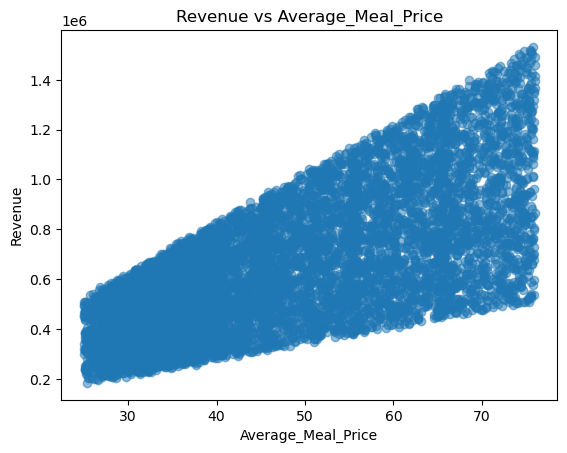

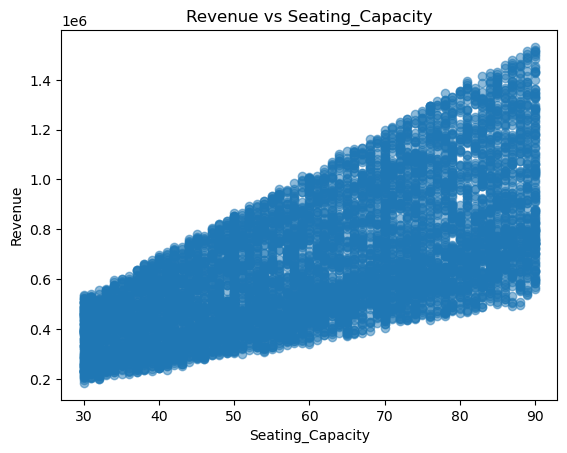

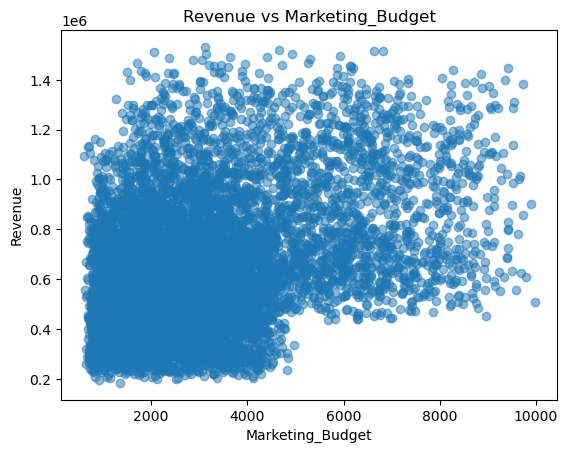

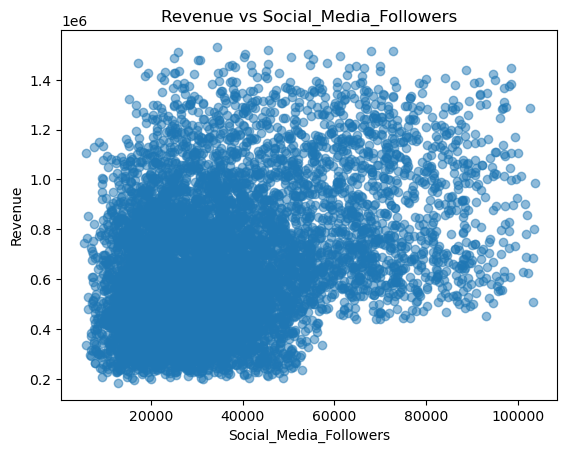

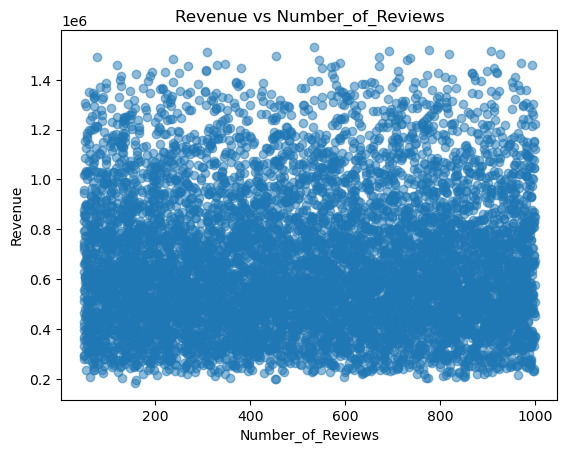

In [105]:
def quick_scatter(xcol):
    plt.figure()
    plt.scatter(X[xcol], y, alpha=0.5)
    plt.title(f"Revenue vs {xcol}")
    plt.xlabel(xcol); plt.ylabel("Revenue")
    plt.show()

for col in ["Average_Meal_Price", "Seating_Capacity", "Marketing_Budget",
            "Social_Media_Followers", "Number_of_Reviews"]:
    if col in X.columns: quick_scatter(col)
